<a href="https://colab.research.google.com/github/mejian1/ExopherGeneExpressionProfiling/blob/main/Clean_Up_Exopher_Quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load in

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_pickle('/content/drive/MyDrive/Mark Abbott Data/my_data.pkl')

Remove Big images (Optional)

In [ ]:
# @title
print(f"Original DataFrame shape: {df.shape}")

# Filter out rows where height or width is greater than 780
df_filtered = df[(df['height'] <= 780) & (df['width'] <= 780)]

# Update the original DataFrame reference
df = df_filtered.copy()

print(f"DataFrame shape after removing rows with height or width > 780: {df.shape}")
print("Displaying the head of the filtered DataFrame:")
display(df.head())

Display Row content

Displaying image from row 0:
Text Content: Left oriented worm
ALML: 173.000 175.000
No PVM
Exopher: 161.000 174.000
Exopher: 148.000 163.000
Exopher Count: 2


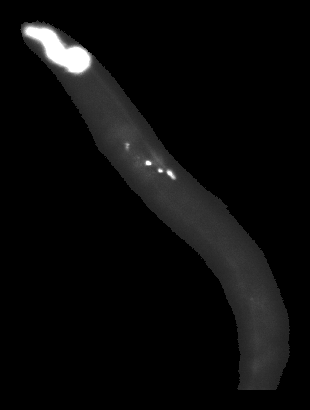

In [ ]:
# @title
from PIL import Image
from IPython.display import display

# Assuming 'position' is already defined, or set it to a desired row index
position = 0 # Example: display the first row's image

# Ensure the 'image_array' is not None before proceeding
if df.loc[position, 'image_array'] is not None:
    # Get the image array from the DataFrame for the selected row
    selected_image_array = df.loc[position, 'image_array']

    # Convert the NumPy array to a PIL Image object
    # For grayscale (1-channel) images, `Image.fromarray` handles it correctly.
    # For 3-channel images, it would also work.
    selected_image = Image.fromarray(selected_image_array)

    print(f"Displaying image from row {position}:")
    print(f"Text Content: {df.loc[position, 'text_content']}")
    print(f"Exopher Count: {df.loc[position, 'exopher_count']}")
    display(selected_image)
else:
    print(f"No image array found for row {position} or it is None.")

Random example viewer

Summer1output_10_0
Left oriented worm
ALML: 173.000 175.000
No PVM
Exopher: 161.000 174.000
Exopher: 148.000 163.000
5
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[     0      0    310    410 125779]
 [    25     27     65     46   1272]
 [   146    161      5      4     19]
 [   159    169      3      3      7]
 [   167    171      7      7     23]]
[[155.45112459 206.07640385]
 [ 60.23742138  49.9913522 ]
 [147.89473684 162.57894737]
 [159.85714286 170.28571429]
 [170.08695652 173.73913043]]


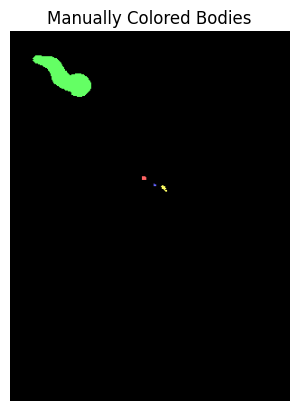

In [ ]:
# @title
import cv2
import numpy as np
import matplotlib.pyplot as plt


# 1. Grab your image from the DataFrame (assuming it's a single 2D array)
image = df.loc[0, 'image_array']
print( df.loc[0, 'basename'])
print( df.loc[0, 'text_content'])


# 2. Create a binary image where pixels >= 200 are pure white (255) and rest are black (0)
# (This acts as the thresholding step you mentioned)
_, binary_image = cv2.threshold(image, 199, 255, cv2.THRESH_BINARY)

# 3. Ensure the image is in the correct format for OpenCV (8-bit integer)
binary_image = np.uint8(binary_image)

# 4. Group the pixels into bodies!
# connectivity=8 means it checks diagonals. Use connectivity=4 for strictly up/down/left/right.
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

plt.imshow(image, cmap='gray')

print(num_labels)
print(labels)
print(stats)
print(centroids)

import numpy as np
import matplotlib.pyplot as plt

# 1. Get the shape of your labels array
height, width = labels.shape

# 2. Create a blank RGB image filled with zeros (which is pure black)
# Shape is (height, width, 3) because we need 3 channels for Red, Green, and Blue
colored_img = np.zeros((height, width, 3), dtype=np.uint8)

# 3. Paint the bodies using RGB color codes!
# Note: Background (0) is already black [0, 0, 0] because of np.zeros
colored_img[labels == 1] = [100, 255,100] # Body 5 = Green
colored_img[labels == 2] = [255, 100, 100]   # Body 2 = Red
colored_img[labels == 3] = [100, 100, 255]   # Body 3 = Blue
colored_img[labels == 4] = [255, 255, 100] # Body 4 = Yellow
colored_img[labels == 5] = [255, 255,255] # Body 5 = White

# Add more lines if you have more specific bodies...

# 4. Display it
plt.imshow(colored_img)
plt.title("Manually Colored Bodies")
plt.axis('off')
plt.show()

Analyze Body Sizes (color min changable currently 150)

In [ ]:
# @title
#Analyzing body sizes

import cv2
import numpy as np
import pandas as pd

# Lists to store the sizes we find
largest_areas = []
second_largest_areas = []

print(f"Analyzing {len(df)} images...")

# Loop through every row in your dataframe
for index, row in df.iterrows():
    image = row['image_array']

    # 1. Threshold: Pixels >= 200 become pure white (255)
    _, binary = cv2.threshold(image, 130, 255, cv2.THRESH_BINARY)
    binary = np.uint8(binary)

    # 2. Find the bodies
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Remember: num_labels includes the background (0).
    # If num_labels > 1, it means at least one actual body was found.
    if num_labels > 1:
        # Extract the 'Area' column from stats, but skip row 0 (the background)
        body_areas = stats[1:, cv2.CC_STAT_AREA]

        # Sort the areas from largest to smallest
        # Example: [500, 120, 15, 2]
        sorted_areas = sorted(body_areas, reverse=True)

        # Save the largest body (index 0)
        largest_areas.append(sorted_areas[0])

        # If there are at least two bodies, save the second largest (index 1)
        if len(sorted_areas) >= 2:
            second_largest_areas.append(sorted_areas[1])

# 3. Convert our lists to Pandas Series to easily calculate all statistics at once
s_largest = pd.Series(largest_areas)
s_second = pd.Series(second_largest_areas)

# 4. Display the results using .describe()
print("\n--- STATISTICS FOR THE LARGEST BODY ---")
# .describe() automatically prints count, mean, std, min, 25%, 50% (median), 75%, and max
print(s_largest.describe().round(2))

print("\n--- STATISTICS FOR THE SECOND LARGEST BODY ---")
print(s_second.describe().round(2))



Analyzing 2492 images...

--- STATISTICS FOR THE LARGEST BODY ---
count    2450.00
mean     1417.01
std       557.53
min         1.00
25%      1227.25
50%      1455.00
75%      1718.00
max      5425.00
dtype: float64

--- STATISTICS FOR THE SECOND LARGEST BODY ---
count    2385.00
mean      180.56
std       354.46
min         1.00
25%        37.00
50%        56.00
75%        93.00
max      2111.00
dtype: float64


Creates Body Data DF

In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd

# We will store our results here as a list of dictionaries
body_stats = []

print("Extracting sizes and matching to basenames...")

for index, row in df.iterrows():
    basename = row['basename']
    image = row['image_array']

    # 1. Threshold
    _, binary = cv2.threshold(image, 199, 255, cv2.THRESH_BINARY)
    binary = np.uint8(binary)

    # 2. Find bodies
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Default sizes to 0 in case the image is completely blank
    largest = 0
    second_largest = 0

    if num_labels > 1:
        body_areas = stats[1:, cv2.CC_STAT_AREA]
        sorted_areas = sorted(body_areas, reverse=True)

        largest = sorted_areas[0]
        if len(sorted_areas) >= 2:
            second_largest = sorted_areas[1]

    # Save the data tied to the specific image name
    body_stats.append({
        'basename': basename,
        'largest_area': largest,
        'second_largest_area': second_largest
    })

# Turn it into a DataFrame
stats_df = pd.DataFrame(body_stats)
print("Done! Stats table created.")

Extracting sizes and matching to basenames...
Done! Stats table created.


Examples of 'bad' images

In [ ]:
# @title
# --- CONDITION 1: VERY SMALL FIRST BODY (< 10 pixels) ---
# This means the thresholding essentially found nothing but a few specks of dust.
small_first_body_df = stats_df[stats_df['largest_area'] < 100]
small_basenames = small_first_body_df['basename'].tolist()

print(f"Found {len(small_basenames)} images with a largest body < 10 pixels.")
print("Basenames:", small_basenames[:10]) # Printing the first 10 so it doesn't flood your screen
print("-" * 40)


# --- CONDITION 2: UNUSUALLY LARGE SECOND BODY ---
# You can change the '500' to whatever number you noticed on your histogram
LARGE_THRESHOLD = 500

large_second_body_df = stats_df[stats_df['second_largest_area'] > LARGE_THRESHOLD]
large_second_basenames = large_second_body_df['basename'].tolist()

print(f"Found {len(large_second_basenames)} images with a second body > {LARGE_THRESHOLD} pixels.")
print("Basenames:", large_second_basenames[:10])

Found 237 images with a largest body < 10 pixels.
Basenames: ['Summer1output_10_1', 'Summer1output_15_2', 'Summer1output_15_3', 'Summer1output_21_0', 'Summer1output_21_2', 'Summer1output_25_1', 'Summer1output_27_0', 'Summer1output_28_5', 'Summer1output_31_0', 'Summer1output_33_0']
----------------------------------------
Found 191 images with a second body > 500 pixels.
Basenames: ['Summer1output_11_1', 'Summer1output_11_2', 'Summer1output_11_3', 'Summer1output_11_4', 'Summer1output_11_6', 'Summer1output_13_1', 'Summer1output_13_2', 'Summer1output_1_2', 'Summer1output_23_1', 'Summer1output_23_5']


In [ ]:
# @title
merged_df = stats_df.merge(df[['basename', 'exopher_count']], on='basename')

# 2. Filter for both conditions:
# Condition A: Largest body is < 100 pixels (virtually empty to the computer)
# Condition B: Exopher count is >= 1 (manually labeled as having data)
mismatch_df = merged_df[
    (merged_df['largest_area'] < 100) &
    (merged_df['exopher_count'] > 0)
]

# 3. Print the results
print(f"Total images with a tiny/missing body BUT a true exopher count >= 1: {len(mismatch_df)}")
print("\nBasenames of these specific images:")
print(mismatch_df['basename'].tolist())

Total images with a tiny/missing body BUT a true exopher count >= 1: 40

Basenames of these specific images:
['Summer1output_25_1', 'Summer1output_28_5', 'Summer1output_33_2', 'Summer3output_18_2', 'Summer3output_21_7', 'Summer3output_23_0', 'Summer3output_46_3', 'Summer3output_61_3', 'Summer3output_6_2', 'Summer4output_20_0', 'Summer4output_27_0', 'Summer4output_38_1', 'Summer4output_42_0', 'Summer4output_54_0', 'Summer5output_16_6', 'Summer5output_20_1', 'Summer5output_24_0', 'Summer5output_26_1', 'Summer5output_26_6', 'Summer5output_38_3', 'Summer5output_45_4', 'Summer5output_50_0', 'Summer5output_62_1', 'Summer5output_66_0', 'Summer5output_7_0', 'Summer6output_13_3', 'Summer6output_16_0', 'Summer6output_32_1', 'Summer6output_36_0', 'Summer6output_42_0', 'Summer6output_54_1', 'Summer6output_58_0', 'Summer7output_44_0', 'Summer7output_45_0', 'Summer8output_23_0', 'Summer8output_24_4', 'Summer8output_48_4', 'Summer8output_50_3', 'Summer8output_59_1', 'Summer8output_67_2']


Remove Images labelled as bad

In [ ]:
# @title
import pandas as pd

# 1. Identify bad basenames based on image structure (from merged_df)
# Condition: Largest body is too tiny OR second largest body is too massive
# bad_structure_mask = (merged_df['largest_area'] < 100) | (merged_df['second_largest_area'] >= 250)
# bad_structure_basenames = merged_df[bad_structure_mask]['basename'].tolist()

# 2. Identify bad basenames based on text content notes (from df)
# Note: We use case=False so it safely catches "Blurry", "BLURRY", "Not a worm", etc.
bad_text_mask = df['text_content'].str.contains('not a worm|blurry|missing', case=False, na=False)

bad_text_basenames = df[bad_text_mask]['basename'].tolist()

# 3. Combine both lists into a unique set of basenames to exclude
all_bad_basenames = set(bad_text_basenames + large_second_basenames + small_basenames)
# print(len(bad_text_basenames))

# 4. Filter the original dataset to keep only the good rows
clean_df = df[~df['basename'].isin(all_bad_basenames)].reset_index(drop=True)
# df.describe()
clean_df.describe()

,exopher_count,height,width
count,1207.000000,1207.000000,1207.000000
mean,1.101906,456.816073,476.095278
std,0.944771,162.713626,166.468957
min,0.000000,122.000000,103.000000
25%,0.000000,329.000000,335.500000
50%,1.000000,455.000000,479.000000
75%,2.000000,578.000000,608.000000
max,5.000000,913.000000,848.000000


Param Testing

In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd

# =====================================================================
# 1. SPEED FIX: Pull arrays out of Pandas into native Python lists ONCE
# =====================================================================
images_list = clean_df['image_array'].tolist()
true_counts_list = clean_df['exopher_count'].tolist()

# Define explicit search grids
color_thresholds = list(range(81, 256, 5))
min_sizes = list(range(0, 22))

# Matrix sized exactly to the grid
accuracy_matrix = np.zeros((len(color_thresholds), len(min_sizes)))

print(f"Starting fast grid search across {len(color_thresholds) * len(min_sizes)} combinations...")

# Grid search through threshold values and minimum object sizes
for c_idx, colorMin in enumerate(color_thresholds):
    for s_idx, minSize in enumerate(min_sizes):
        heuristic_predictions = []

        # Loop through native lists for massive speed boost
        for image in images_list:

            # --- 1. Thresholding ---
            _, binary = cv2.threshold(image, colorMin, 255, cv2.THRESH_BINARY)
            binary = np.uint8(binary)

            # --- 2. First Pass Component Analysis ---
            num_labels_initial, labels_initial, stats_initial, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

            # --- 3. Create Blank Canvases ---
            large_mask = np.zeros_like(binary)
            small_mask = np.zeros_like(binary)

            # --- 4. Separate the Bodies by Size ---
            LARGE_SIZE_THRESHOLD = 100

            for i in range(1, num_labels_initial): # Skip 0 (background)
                area = stats_initial[i, cv2.CC_STAT_AREA]
                if area >= LARGE_SIZE_THRESHOLD:
                    large_mask[labels_initial == i] = 255
                else:
                    small_mask[labels_initial == i] = 255

            # --- 5. Apply Relative Slack (Morphological Closing) ---
            large_kernel = np.ones((7, 7), np.uint8)
            large_closed = cv2.morphologyEx(large_mask, cv2.MORPH_CLOSE, large_kernel)

            small_kernel = np.ones((3, 3), np.uint8)
            small_closed = cv2.morphologyEx(small_mask, cv2.MORPH_CLOSE, small_kernel)

            # --- 6. Recombine the Canvases ---
            final_binary = cv2.bitwise_or(large_closed, small_closed)

            # --- 7. Final Pass Component Analysis ---
            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(final_binary, connectivity=8)

            if num_labels > 1:
                body_areas = stats[1:, cv2.CC_STAT_AREA]
                bodies_above_min = np.sum(body_areas > minSize)
                prediction = max(0, bodies_above_min - 4)
            else:
                prediction = 0

            # =========================================================
            # THE FIX: Actually append the predictions to the lists!
            # =========================================================
            heuristic_predictions.append(prediction)

        # Calculate Accuracy
        predictions_arr = np.array(heuristic_predictions)
        true_arr = np.array(true_counts_list)
        exact_match = np.mean(predictions_arr == true_arr) * 100

        # Print progress so you know it isn't frozen
        print(f"Threshold: {colorMin:>3} | MinSize: {minSize:>2} -> Accuracy: {exact_match:.2f}%")

        # Store in matrix
        accuracy_matrix[c_idx, s_idx] = exact_match

# Find the best parameters cleanly by mapping back to our grid lists
best_flat_idx = np.argmax(accuracy_matrix, axis=None)
best_idx = np.unravel_index(best_flat_idx, accuracy_matrix.shape)

best_colorMin = color_thresholds[best_idx[0]]
best_minSize = min_sizes[best_idx[1]]
best_acc = accuracy_matrix[best_idx]

print("\n--- SEARCH COMPLETE ---")
print(f"Highest Accuracy: {best_acc:.2f}%")
print(f"Best colorMin (Threshold): {best_colorMin}")
print(f"Best minSize (Pixel area): {best_minSize}")

Starting fast grid search across 770 combinations...


KeyboardInterrupt: 

In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd

# 1. Initialize matrix
accuracy_matrix = np.zeros((256, 51))

# 2. Extract to native lists for maximum speed
images_list = clean_df['image_array'].tolist()
true_counts_list = clean_df['exopher_count'].tolist()

print("Starting basic grid search...")

# Grid search through threshold values and minimum object sizes
for colorMin in range(80, 160, 10):
    for minSize in range(2, 22):
        heuristic_predictions = []

        # Fast loop through images
        for image in images_list:

            # Thresholding
            _, binary = cv2.threshold(image, colorMin, 255, cv2.THRESH_BINARY)
            binary = np.uint8(binary)
            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

            if num_labels > 1:
                body_areas = stats[1:, cv2.CC_STAT_AREA]
                bodies_in_range = np.sum((body_areas > minSize) & (body_areas < 250))
                prediction = max(0, bodies_in_range - 3)
            else:
                prediction = 0

            # ==========================================
            # THE FIX: Append predictions!
            # ==========================================
            heuristic_predictions.append(prediction)


        # Calculate Accuracy
        predictions_arr = np.array(heuristic_predictions)
        true_arr = np.array(true_counts_list)
        exact_match = np.mean(predictions_arr == true_arr) * 100

        print(f"Threshold: {colorMin} | MinSize: {minSize} -> Accuracy: {exact_match:.2f}%")

        # Store in matrix
        accuracy_matrix[colorMin, minSize] = exact_match

# Find the best parameters
best_idx = np.unravel_index(np.argmax(accuracy_matrix, axis=None), accuracy_matrix.shape)
best_colorMin = best_idx[0]
best_minSize = best_idx[1]
best_acc = accuracy_matrix[best_idx]

print("--- SEARCH COMPLETE ---")
print(f"Highest Accuracy: {best_acc:.2f}%")
print(f"Best colorMin (Threshold): {best_colorMin}")
print(f"Best minSize (Pixel area): {best_minSize}")

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data for the heatmap
# We'll slice the matrix to only show the ranges we actually searched
# Our loop was colorMin (56-255, step 5) and minSize (0-29)
searched_colorMin = np.arange(80, 160, 10)
searched_minSize = np.arange(0, 30)

# Extract the relevant sub-matrix
plot_data = accuracy_matrix[80:160:10, 0:30]

plt.figure(figsize=(14, 10))
sns.heatmap(
    plot_data,
    annot=False,
    cmap='viridis',
    xticklabels=searched_minSize,
    yticklabels=searched_colorMin
)

plt.title('Heuristic Model Accuracy: colorMin vs. minSize')
plt.xlabel('minSize (Minimum Pixel Area)')
plt.ylabel('colorMin (Brightness Threshold)')

# Highlight the best point
best_y = (best_colorMin - 56) // 5
best_x = best_minSize
plt.scatter(best_x + 0.5, best_y + 0.5, color='red', marker='x', s=200, label=f'Best: {best_acc:.1f}%')
plt.legend()

plt.show()

Individual Example (Not Updated Prediction Alogirihm

In [ ]:
TARGET_INDEX = 461  # Change this number to inspect any image in your dataframe


Spine successfully traced! Total length: 88 pixels.
 DIAGNOSTIC REPORT FOR INDEX: 461
File Basename:   Summer4output_65_4
User Notes:      Left oriented worm
ALML: 405.000 224.000
PVM: 257.000 75.000
Exopher: 389.000 230.000
True Count:      1 exopher(s)
Predicted Count: 0 exopher(s)
--------------------------------------------------
HEURISTIC MATH BREAKDOWN:
 -> Total raw components found (incl. background): 7
 -> Components with an area > 20 pixels: 1
 -> Calculation: max(0, 1 - 3) = 0
--------------------------------------------------
DETAILED BODY STATS (Sorted by Largest to Smallest):
Label ID  Area (px)   Centroid (X, Y)Status         
6         1807        (512.1, 453.9) Counted (>20px)
4         20          (386.8, 226.1) Ignored (Dust) 
1         7           (26.3, 32.9)   Ignored (Dust) 
3         3           (401.7, 220.7) Ignored (Dust) 
2         3           (259.3, 74.3)  Ignored (Dust) 
5         1           (415.0, 297.0) Ignored (Dust) 


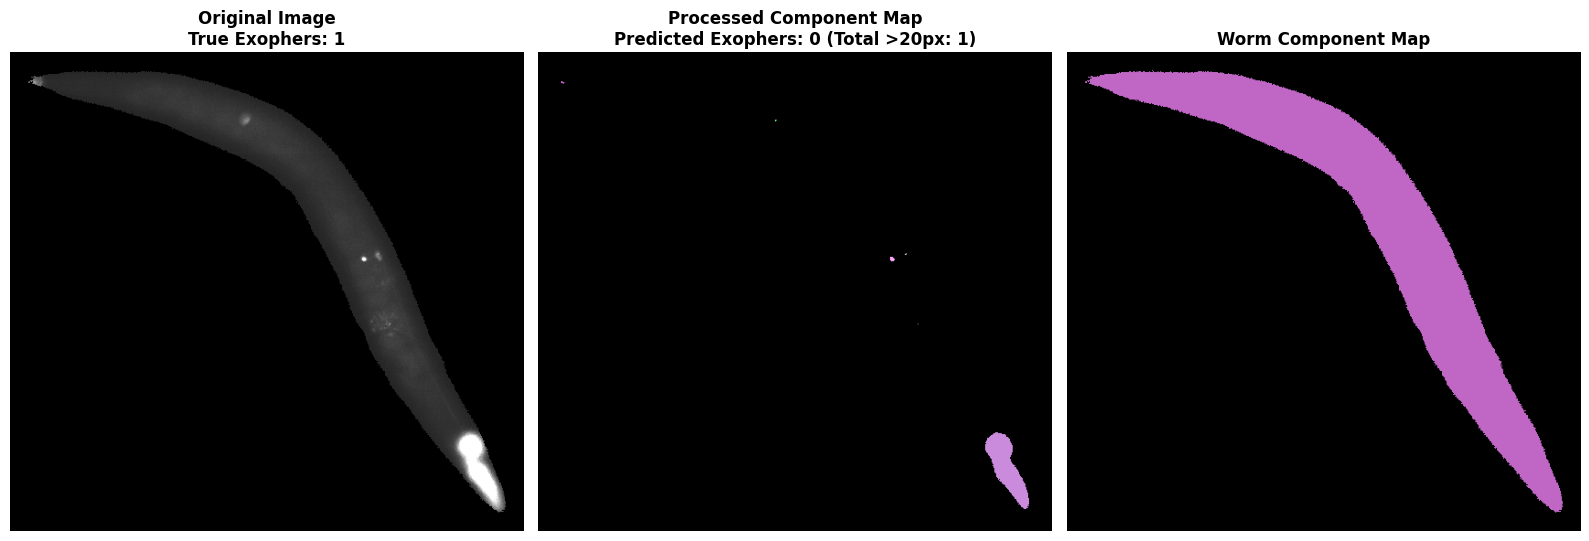

In [ ]:
# @title
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
import numpy as np

# =====================================================================
# 1. PICK YOUR INDEX HERE
# =====================================================================
# TARGET_INDEX = 14  # Change this number to inspect any image in your dataframe
# =====================================================================

# Extract data from your dataframe (adjust 'clean_df' to 'df' if needed)
current_row = clean_df.iloc[TARGET_INDEX]
image = current_row['image_array']
basename = current_row['basename']
text_content = current_row['text_content']
true_exophers = current_row['exopher_count']

#detect worm
_, binary = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
binary = np.uint8(binary)
num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary, connectivity=8)
largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
worm_mask_bool = (labels_worm == largest_label)
skeleton_bool = skeletonize(worm_mask_bool)
skeleton_int = skeleton_bool.astype(np.uint8)
kernel = np.array([[1, 1, 1],
                   [1, 10, 1],
                   [1, 1, 1]], dtype=np.uint8)
neighbor_map = cv2.filter2D(skeleton_int, -1, kernel)
endpoints_y_x = np.argwhere(neighbor_map == 11)

if len(endpoints_y_x) >= 2:
    # Convert skeleton points to a set for incredibly fast lookups
    skeleton_pts = set(tuple(pt) for pt in np.argwhere(skeleton_int))

    # Start the path at Endpoint A
    start_pt = tuple(endpoints_y_x[0])
    path = [start_pt]
    skeleton_pts.remove(start_pt)

    # Hop from neighbor to neighbor until the end
    while skeleton_pts:
        current = path[-1]
        y, x = current

        # Check the 8 surrounding pixels
        neighbors = [
            (y+dy, x+dx) for dy in [-1, 0, 1] for dx in [-1, 0, 1]
            if (dy != 0 or dx != 0) and (y+dy, x+dx) in skeleton_pts
        ]

        if not neighbors:
            break # Reached the end!

        next_pt = neighbors[0]
        path.append(next_pt)
        skeleton_pts.remove(next_pt)

    print(f"Spine successfully traced! Total length: {len(path)} pixels.")
    # 'path' is now an ordered list of (y, x) coordinates from Head to Tail!
else:
    print("Could not find exactly two endpoints. The worm might be a loop!")




# 2. Run Image Processing & Component Analysis
_, binary = cv2.threshold(image, 140, 255, cv2.THRESH_BINARY)
binary = np.uint8(binary)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

# 3. Calculate the Heuristic Prediction
if num_labels > 1:
    body_areas = stats[1:, cv2.CC_STAT_AREA]
    bodies_above_20 = np.sum((body_areas > 7) & (body_areas < 250))
    predicted_exophers = max(0, bodies_above_20 - 3)
else:
    body_areas = []
    bodies_above_20 = 0
    predicted_exophers = 0

# 4. Generate Dynamic Colors for ALL Unique Bodies (Scales past 5 automatically)
np.random.seed(42)  # Keeps colors stable for the same body IDs
random_colors = np.random.randint(100, 255, size=(num_labels, 3), dtype=np.uint8)
random_colors[0] = [0, 0, 0]  # Ensure background (Label 0) remains pure black
colored_img = random_colors[labels]
colored_worm = random_colors[labels_worm]

# =====================================================================
# DISPLAY RESULTS
# =====================================================================

print(f"==================================================")
print(f" DIAGNOSTIC REPORT FOR INDEX: {TARGET_INDEX}")
print(f"==================================================")
print(f"File Basename:   {basename}")
print(f"User Notes:      {text_content}")
print(f"True Count:      {true_exophers} exopher(s)")
print(f"Predicted Count: {predicted_exophers} exopher(s)")
print(f"--------------------------------------------------")
print(f"HEURISTIC MATH BREAKDOWN:")
print(f" -> Total raw components found (incl. background): {num_labels}")
print(f" -> Components with an area > 20 pixels: {bodies_above_20}")
print(f" -> Calculation: max(0, {bodies_above_20} - 3) = {predicted_exophers}")
print(f"--------------------------------------------------")
print(f"DETAILED BODY STATS (Sorted by Largest to Smallest):")

if num_labels > 1:
    print(f"{'Label ID':<10}{'Area (px)':<12}{'Centroid (X, Y)':<15}{'Status':<15}")
    # Loop through bodies sorted by area size
    sorted_indices = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1] + 1
    for rank, label_idx in enumerate(sorted_indices):
        area = stats[label_idx, cv2.CC_STAT_AREA]
        cx, cy = centroids[label_idx]
        status = "Counted (>20px)" if area > 20 else "Ignored (Dust)"

        # Only print the top 15 bodies so it doesn't flood your console screen
        if rank < 15:
            print(f"{label_idx:<10}{area:<12}{f'({cx:.1f}, {cy:.1f})':<15}{status:<15}")
    if len(sorted_indices) > 15:
        print(f"... and {len(sorted_indices) - 15} more tiny bodies.")
else:
    print("No bodies detected in this image.")

# Plot the visual side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# Left plot: Raw Grayscale Microscope View
axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Original Image\nTrue Exophers: {true_exophers}", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right plot: Colored Component Map
axes[1].imshow(colored_img)
axes[1].set_title(f"Processed Component Map\nPredicted Exophers: {predicted_exophers} (Total >20px: {bodies_above_20})", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(colored_worm)
axes[2].set_title(f"Worm Component Map", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

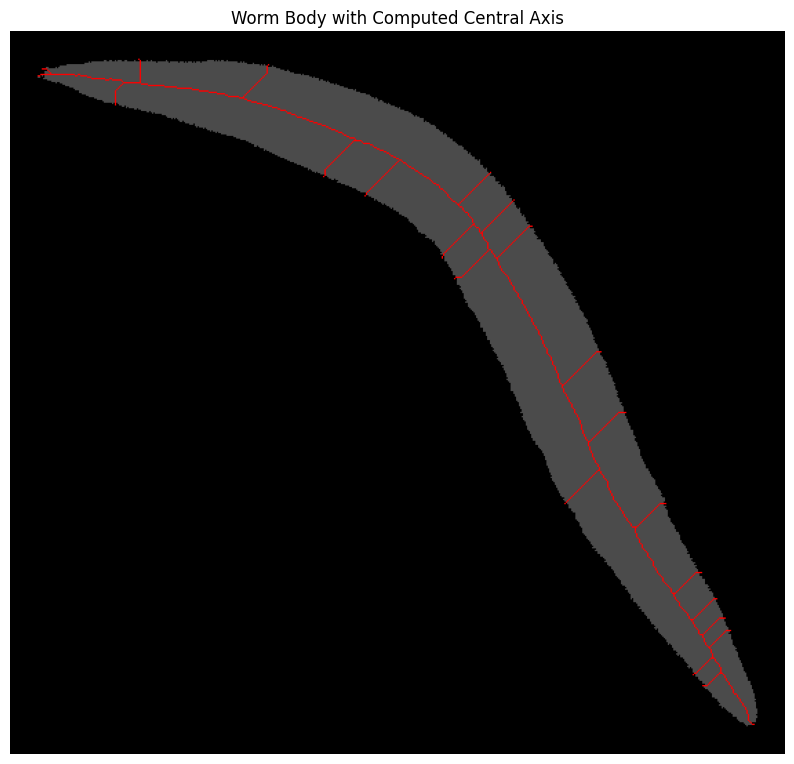

In [ ]:
# @title
overlay = np.zeros((worm_mask_bool.shape[0], worm_mask_bool.shape[1], 3), dtype=np.uint8)

# Paint the thick worm body dark gray
overlay[worm_mask_bool] = [75, 75, 75]

# Paint the 1-pixel skeleton spine bright red
overlay[skeleton_bool] = [255, 0, 0]

# Display the image
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.title("Worm Body with Computed Central Axis")
plt.axis('off')
plt.show()

Brightest Centroid (Head) at: 512.1, 453.9
Dist to index 0: 3039.4 | Dist to index -1: 420142.7
Spine was already correct! Head is at index 0.
Spine oriented! Head at (np.int64(502), np.int64(539)), Tail at (np.int64(32), np.int64(20))
Total length: 692 pixels along the curve.


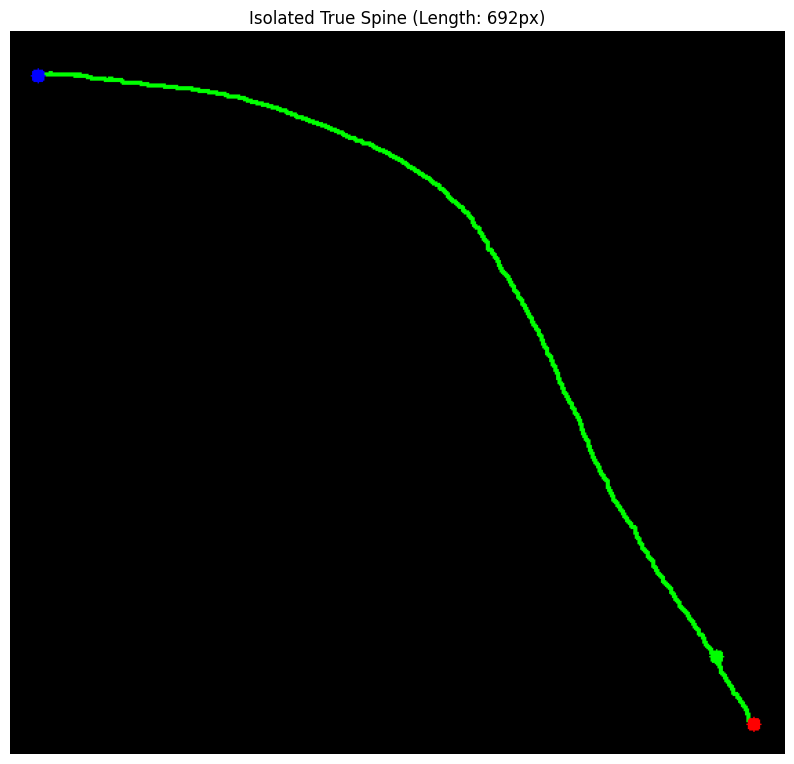

In [ ]:
# @title
from collections import deque
import cv2
import numpy as np
from skimage.morphology import skeletonize

# --- 1. Get the Raw Skeleton (as you did before) ---
_, binary = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
binary = np.uint8(binary)
num_labels_worm, labels_worm, stats_worm, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
worm_mask_bool = (labels_worm == largest_label)
skeleton_bool = skeletonize(worm_mask_bool)

# --- 2. Convert Skeleton to a Set of Graph Nodes ---
skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
pt_set = set(skeleton_pts)

def get_valid_neighbors(pt):
    """Finds all 8-connected neighboring pixels that belong to the skeleton."""
    y, x = pt
    neighbors = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            nxt = (y + dy, x + dx)
            if nxt in pt_set:
                neighbors.append(nxt)
    return neighbors

def find_longest_path_from(start_node):
    """Runs a BFS to find the farthest pixel and the exact path to it."""
    queue = deque([(start_node, [start_node])])
    visited = {start_node}

    farthest_node = start_node
    longest_path = [start_node]

    while queue:
        curr, path = queue.popleft()

        # If this path is longer than our current record, update it
        if len(path) > len(longest_path):
            longest_path = path
            farthest_node = curr

        for neighbor in get_valid_neighbors(curr):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))

    return farthest_node, longest_path

# --- 3. The Two-Pass Magic ---
if skeleton_pts:
    # Pass 1: Start at a random skeleton pixel to find one true endpoint (Head or Tail)
    random_start = skeleton_pts[0]
    endpoint_A, _ = find_longest_path_from(random_start)

    # Pass 2: Start at endpoint_A to find the absolute farthest point (endpoint_B) and the true spine
    endpoint_B, true_spine = find_longest_path_from(endpoint_A)


    cX, cY = centroids[largest_body_index]
    print(f"Brightest Centroid (Head) at: {cX:.1f}, {cY:.1f}")

    # 2. Extract the current start and end points of the spine (stored as Y, X)
    # FIX: Index 0 is the start, index -1 is the end
    start_pt = true_spine[0]
    end_pt = true_spine[-1]

    # 3. Calculate squared Euclidean distance from the centroid to both ends
    # (We use pt[1] for X and pt[0] for Y)
    dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
    dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

    print(f"Dist to index 0: {dist_to_start:.1f} | Dist to index -1: {dist_to_end:.1f}")

    # 4. If the END of the list is closer to the head centroid than the START,
    # it means the array is backwards. Flip it!
    if dist_to_end < dist_to_start:
        true_spine = true_spine[::-1]
        print("Spine flipped! Head is now correctly at index 0.")
    else:
        print("Spine was already correct! Head is at index 0.")

    print(f"Spine oriented! Head at {true_spine[0]}, Tail at {true_spine[-1]}")
    print(f"Total length: {len(true_spine)} pixels along the curve.")

    # 'true_spine' is now your clean 0-to-1 coordinate list!
else:
    print("No skeleton found!")

import cv2
import matplotlib.pyplot as plt
import numpy as np



# 1. Create a blank black image of the exact same size as your original image
# We make it a 3-channel (RGB) image so we can draw the line in color
spine_canvas = np.zeros(
    (binary.shape[0], binary.shape[1], 3), dtype=np.uint8
)

# 2. Format the path for OpenCV
# 'true_spine' contains (y, x) coordinates, but OpenCV functions expect (x, y)
opencv_pts = np.array([[x, y] for y, x in true_spine], dtype=np.int32)
opencv_pts = opencv_pts.reshape((-1, 1, 2))

# 3. Draw the clean, spur-free spine line
# You can change 'thickness' to make the line bolder if your image resolution is high
cv2.polylines(
    spine_canvas,
    [opencv_pts],
    isClosed=False,
    color=(0, 255, 0),
    thickness=2,
)

# 4. Draw the Head and Tail points explicitly so you can see where they landed
head_y, head_x = true_spine[0]
tail_y, tail_x = true_spine[-1]



cv2.circle(spine_canvas, (head_x, head_y), 5, (255, 0, 0), -1)  # Red dot for Head
cv2.circle(spine_canvas, (tail_x, tail_y), 5, (0, 0, 255), -1)  # Blue dot for Tail
cv2.circle(spine_canvas, (int(cX), int(cY)), 5, (0, 255, 0), -1)  # Red dot for centroid of head


# 5. Display the final isolated spine
plt.figure(figsize=(10, 10))
plt.imshow(spine_canvas)
plt.title(f"Isolated True Spine (Length: {len(true_spine)}px)")
plt.axis("off")
plt.show()

In [ ]:
# @title
from scipy.spatial import KDTree
import numpy as np

# 1. Convert your true_spine list into a fast NumPy array (Shape: N x 2)
# Remember: true_spine coordinates are stored as (Y, X)
spine_array = np.array(true_spine)
total_spine_points = len(spine_array)

# 2. Build the spatial index tree out of the worm's spine
# (Do this once per image)
spine_tree = KDTree(spine_array)

# 3. Prepare your centroids matrix (Shape: M x 2)
# Exclude label 0 (background) and your largest_label (the worm body itself)
exopher_indices = [i for i in range(1, num_labels) if i != largest_body_index]

if exopher_indices:
    raw_centroids = centroids[exopher_indices] # Current shape: (M, 2) as (X, Y)

    # CRITICAL: Flip OpenCV's (X, Y) centroids to match the spine's (Y, X) layout
    centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

    # 4. Query the tree!
    # This automatically finds the closest spine point for ALL centroids at once using C-speed
    distances, closest_spine_indices = spine_tree.query(centroids_flipped)

    # 5. Math Magic: Convert the spine index into a 0.0 to 1.0 percentage scale
    # Index 0 becomes 0.0 (Head), Middle index becomes 0.5, Last index becomes 1.0 (Tail)
    percentages = closest_spine_indices / (total_spine_points - 1)
    print(percentages)

    # --- Print your results ---
    for idx, label_idx in enumerate(exopher_indices):
        pct = percentages[idx]
        dist = distances[idx]
        print(f"Object {label_idx} is located at {pct*100:.1f}% of the worm length (Distance to spine: {dist:.1f}px)")
else:
    print("No other bodies detected next to the worm.")

[0.39660057 0.97733711]
Object 1 is located at 39.7% of the worm length (Distance to spine: 1.0px)
Object 2 is located at 97.7% of the worm length (Distance to spine: 0.6px)


determining orientation


In [ ]:
# @title
import numpy as np
from scipy.spatial import KDTree
import cv2



# Define your parameter grid
min_colors = [140]
min_ranges = [0.55]
max_ranges = [4]

# To store the results of all 36 combinations
results_leaderboard = []

print("==================================================")
print(f"STARTING GRID SEARCH (36 Combinations)")
print("==================================================")

# --- 1. THE OUTER PARAMETER LOOPS ---
for min_color in min_colors:
    for min_range in min_ranges:
        for max_range in max_ranges:

            min_exopher_area = max_range


            correct_predictions = 0
            total_processed = 0
            failed_images = 0

            # --- 2. THE IMAGE PROCESSING LOOP ---
            for index, row in clean_df.iterrows():
                image = row['image_array']
                text_content = str(row['text_content']).lower()

                # Ground truth: Does the text explicitly say "left"?
                true_is_left = "left" in text_content
                percentages = []

                try:
                    # =========================================================
                    # WORM SPINE SKELETONIZATION
                    # =========================================================
                    _, binary_worm = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
                    binary_worm = np.uint8(binary_worm)
                    num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

                    if num_labels_worm <= 1:
                        raise ValueError("No worm found")

                    largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
                    worm_mask_bool = (labels_worm == largest_label)
                    skeleton_bool = skeletonize(worm_mask_bool)

                    skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
                    pt_set = set(skeleton_pts)

                    # (Assuming find_longest_path_from is defined in your notebook from before)
                    if skeleton_pts:
                        random_start = skeleton_pts[0]
                        endpoint_A, _ = find_longest_path_from(random_start)
                        endpoint_B, true_spine = find_longest_path_from(endpoint_A)

                        # =========================================================
                        # COMPONENT ANALYSIS (USING DYNAMIC 'min_color')
                        # =========================================================
                        # ---> Swapped '150' for 'min_color' here <---
                        _, binary_bodies = cv2.threshold(image, min_color, 255, cv2.THRESH_BINARY)
                        binary_bodies = np.uint8(binary_bodies)
                        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

                        if num_labels > 1:
                            largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
                            cX, cY = centroids[largest_body_index]

                            # Orientation Check
                            start_pt = true_spine[0]
                            end_pt = true_spine[-1]

                            dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
                            dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

                            if dist_to_end < dist_to_start:
                                true_spine = true_spine[::-1]

                            # KD-Tree Distance Mapping
                            spine_array = np.array(true_spine)
                            total_spine_points = len(spine_array)
                            spine_tree = KDTree(spine_array)

                            exopher_indices = [
                                i for i in range(1, num_labels)
                                if i != largest_body_index and stats[i, cv2.CC_STAT_AREA] >= min_exopher_area
                            ]

                            if exopher_indices:
                                raw_centroids = centroids[exopher_indices]
                                centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))
                                distances, closest_spine_indices = spine_tree.query(centroids_flipped)
                                percentages = closest_spine_indices / (total_spine_points - 1)

                    # =========================================================
                    # PREDICTION LOGIC (USING DYNAMIC 'min_range' AND 'max_range')
                    # =========================================================
                    # ---> Swapped hardcoded values for 'min_range' and 'max_range' here <---
                    predicted_left = any(min_range <= pct <= 0.85 for pct in percentages)

                    if not any(pct >= .95 for pct in percentages):
                        continue

                    if predicted_left == true_is_left:
                        correct_predictions += 1
                    else:
                        print(index)

                    # if index == 38:
                    #     print(predicted_left, true_is_left)
                    #     print(percentages)

                    total_processed += 1

                except Exception as e:
                    failed_images += 1

            # --- 3. STORE AND PRINT RESULTS FOR THIS COMBINATION ---
            if total_processed > 0:
                accuracy = (correct_predictions / total_processed) * 100
                results_leaderboard.append({
                    "accuracy": accuracy,
                    "color": min_color,
                    "min_pct": min_range,
                    "max_pct": max_range
                })
                print(f"Tested: Color={min_color}, Range=[{min_range:.2f} - {max_range:.2f}] --> Accuracy: {accuracy:.2f}%")

# =====================================================================
# FINAL ACCURACY LEADERBOARD
# =====================================================================
print("\n==================================================")
print("TOP 5 PARAMETER COMBINATIONS:")
print("==================================================")

# Sort the leaderboard from highest accuracy to lowest
sorted_results = sorted(results_leaderboard, key=lambda x: x["accuracy"], reverse=True)

# Print the top 5
for i, result in enumerate(sorted_results[:5]):
    print(f"Rank {i+1}: {result['accuracy']:.2f}% (Color: {result['color']}, Range: {result['min_pct']:.2f} to {result['max_pct']:.2f})")

STARTING GRID SEARCH (36 Combinations)
12
22
36
80


KeyboardInterrupt: 

best 140 .55 .85 size 4 min 93.7 acc

60-90 gave 87%

55-90 gave 87%

50-90 gave 83%

best 160 .6 .85

Big run with all considered

In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd

np.set_printoptions(suppress=True, precision=2)
# Suppress scientific notation and limit decimals


# 1. Initialize matrix
accuracy_matrix = np.zeros((256, 51))

# 2. Extract to native lists for maximum speed
images_list = clean_df['image_array'].tolist()
true_counts_list = clean_df['exopher_count'].tolist()




min_color=135


print("Starting basic grid search...")
heuristic_predictions = []
# Grid search through threshold values and minimum object sizes
for image in images_list:


    _, binary_worm = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
    binary_worm = np.uint8(binary_worm)
    num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

    if num_labels_worm <= 1:
        raise ValueError("No worm found")

    largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
    worm_mask_bool = (labels_worm == largest_label)
    skeleton_bool = skeletonize(worm_mask_bool)

    skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
    pt_set = set(skeleton_pts)

    # (Assuming find_longest_path_from is defined in your notebook from before)
    if skeleton_pts:
        random_start = skeleton_pts[0]
        endpoint_A, _ = find_longest_path_from(random_start)
        endpoint_B, true_spine = find_longest_path_from(endpoint_A)

        # =========================================================
        # COMPONENT ANALYSIS (USING DYNAMIC 'min_color')
        # =========================================================
        # ---> Swapped '150' for 'min_color' here <---
        _, binary_bodies = cv2.threshold(image, min_color, 255, cv2.THRESH_BINARY)
        binary_bodies = np.uint8(binary_bodies)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

        if num_labels > 1:
            largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            cX, cY = centroids[largest_body_index]

            # Orientation Check
            start_pt = true_spine[0]
            end_pt = true_spine[-1]

            dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
            dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

            if dist_to_end < dist_to_start:
                true_spine = true_spine[::-1]

            # KD-Tree Distance Mapping
            spine_array = np.array(true_spine)
            total_spine_points = len(spine_array)
            spine_tree = KDTree(spine_array)

            exopher_indices = [i for i in range(1, num_labels)]
                              #  if i != largest_body_index


            if exopher_indices:
                raw_centroids = centroids[exopher_indices] # Shape: (M, 2) -> [X, Y]
                centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

                distances, closest_spine_indices = spine_tree.query(centroids_flipped)
                percentages = closest_spine_indices / (total_spine_points - 1)

                # --- NEW EXTRACTION BLOCK ---
                # Pull the raw areas for just these exophers
                exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA] # Shape: (M,)

                # --- NEW EXTRACTION BLOCK ---
                # Pull the raw areas for just these exophers
                exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA]

                # Calculate True Rotated Aspect Ratio (Handles Diagonals!)
                exopher_aspect_ratios = []

                for label_id in exopher_indices:
                    # Get all (Y, X) pixel coordinates for this specific body
                    pts_yx = np.column_stack(np.where(labels == label_id))

                    if len(pts_yx) >= 5: # Need at least a few points to make a rectangle safely
                        # Convert to (X, Y) and float32 format for cv2.minAreaRect
                        pts_xy = np.float32(pts_yx[:, ::-1])

                        # Get the shrink-wrapped rotated rectangle
                        # Returns: (center(x, y), (width, height), angle of rotation)
                        rect = cv2.minAreaRect(pts_xy)
                        w, h = rect[1]

                        # Prevent division by zero
                        min_dim = max(min(w, h), 1)
                        max_dim = max(w, h)
                        ratio = max_dim / min_dim
                    else:
                        ratio = 1.0 # Too small to measure accurately

                    exopher_aspect_ratios.append(ratio)

                exopher_aspect_ratios = np.array(exopher_aspect_ratios)

                # Stack everything together horizontally:
                # Columns: [Label ID, Area, Centroid_X, Centroid_Y, Distance_To_Spine, Spine_Percentage]
                exopher_data_matrix = np.column_stack((
                    exopher_indices,      # The original label ID
                    exopher_areas,        # Size of the body
                    raw_centroids[:, 0],  # X coordinate
                    raw_centroids[:, 1],  # Y coordinate
                    distances,            # Distance away from the spine in pixels
                    percentages,           # 0.0 to 1.0 location on the worm
                    exopher_aspect_ratios   # 6: Aspect Ratio (Length / Width) <--- NEW
                ))

    strict_filter = (
        (exopher_data_matrix[:, 1] >= 5) & (exopher_data_matrix[:, 1] <= 200) &  # Size: 10 to 200px
        (exopher_data_matrix[:, 5] >= 0.225) & (exopher_data_matrix[:, 5] <= 0.9) # Location: 20% to 85%
    )

    valid_exophers = exopher_data_matrix[strict_filter]

    budding_extras = np.sum((valid_exophers[:, 6] >= 1.8) & (valid_exophers[:, 1]>=75))

    predicted_exophers = len(valid_exophers)-2 + budding_extras

    prediction = max(predicted_exophers,0)

    # print(exopher_data_matrix)
    # print(4)



    # ==========================================
    # THE FIX: Append predictions!
    # ==========================================
    heuristic_predictions.append(prediction)


# Calculate Accuracy
predictions_arr = np.array(heuristic_predictions)
true_arr = np.array(true_counts_list)



# check for presence instead of exact

for i in range(len  (predictions_arr)):
    if predictions_arr[i] >= 1:
        predictions_arr[i] = 1
    if true_arr[i] >= 1:
        true_arr[i] = 1


exact_match = np.mean(predictions_arr == true_arr) * 100



print(exact_match)
# Find the best parameters


Starting basic grid search...


NameError: name 'KDTree' is not defined

In [ ]:
target_index = 150
min_color=125

🔎 DETAILED REPORT FOR CLEAN_DF INDEX: 150
Filename: Summer3output_25_1
Ground Truth Exopher Count:  2
Heuristic Predicted Count:   0
User Text Content Notes:     'Left oriented worm
ALML: 353.333 80.000
PVM: 578.333 55.833
Exopher: 555.833 49.167
Exopher: 365.833 73.333'
--------------------------------------------------
📊 EXOPHER DATA MATRIX (ALL DETECTED BODIES):
[Label_ID, Area, Centroid_X, Centroid_Y, Distance_To_Spine, Spine_Percentage]
[[   1.     35.    555.31   47.23    8.78    0.69    1.2 ]
 [   2.      3.    576.33   54.33    3.54    0.71    1.  ]
 [   3.     33.    364.97   70.52    7.77    0.44    1.2 ]
 [   4.      1.    795.     72.      0.      0.99    1.  ]
 [   5.      1.    802.     72.      2.      1.      1.  ]
 [   6.      2.    350.5    78.     12.01    0.42    1.  ]
 [   7.   2251.     79.6   151.09    0.41    0.08    2.9 ]]
--------------------------------------------------
✅ Filtered Bodies Retained: 2 (Before '-2' logic)
[[  1.    35.   555.31  47.23   8.78   

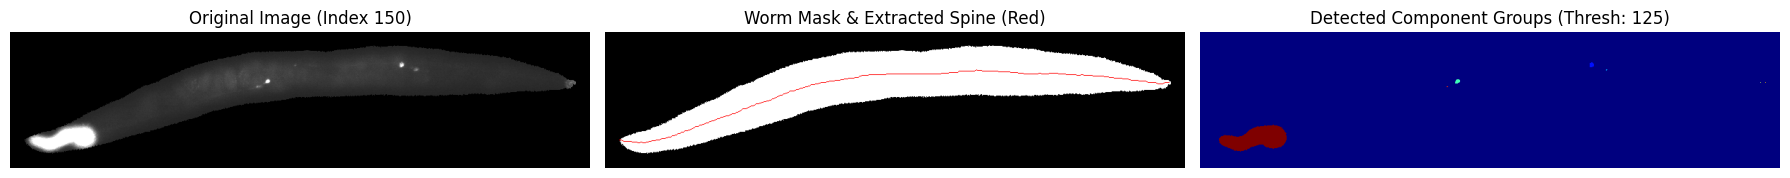

In [ ]:
# @title
import matplotlib.pyplot as plt
import cv2
import numpy as np
from scipy.spatial import KDTree

# Suppress scientific notation and limit decimals
np.set_printoptions(suppress=True, precision=2)

# =====================================================================
# CONFIGURATION: Change this index to inspect different images!
# =====================================================================
# target_index = 1  # <--- Change this number to inspect any worm
# =====================================================================

# 1. Pull data for the single specified index
row = clean_df.iloc[target_index]
image = row['image_array']
true_count = row['exopher_count']
text_content = str(row['text_content'])

exopher_data_matrix = None
valid_exophers = []
prediction = 0

# 2. Run the EXACT same processing logic from your loop
_, binary_worm = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
binary_worm = np.uint8(binary_worm)
num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

if num_labels_worm <= 1:
    raise ValueError("No worm found")

largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
worm_mask_bool = (labels_worm == largest_label)
skeleton_bool = skeletonize(worm_mask_bool)

skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
pt_set = set(skeleton_pts)

# (Assuming find_longest_path_from is defined in your notebook from before)
if skeleton_pts:
    random_start = skeleton_pts[0]
    endpoint_A, _ = find_longest_path_from(random_start)
    endpoint_B, true_spine = find_longest_path_from(endpoint_A)

    # =========================================================
    # COMPONENT ANALYSIS (USING DYNAMIC 'min_color')
    # =========================================================
    # ---> Swapped '150' for 'min_color' here <---
    _, binary_bodies = cv2.threshold(image, min_color, 255, cv2.THRESH_BINARY)
    binary_bodies = np.uint8(binary_bodies)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

    if num_labels > 1:
        largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        cX, cY = centroids[largest_body_index]

        # Orientation Check
        start_pt = true_spine[0]
        end_pt = true_spine[-1]

        dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
        dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

        if dist_to_end < dist_to_start:
            true_spine = true_spine[::-1]

        # KD-Tree Distance Mapping
        spine_array = np.array(true_spine)
        total_spine_points = len(spine_array)
        spine_tree = KDTree(spine_array)

        exopher_indices = [i for i in range(1, num_labels)]
                          #  if i != largest_body_index


        if exopher_indices:
            raw_centroids = centroids[exopher_indices] # Shape: (M, 2) -> [X, Y]
            centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

            distances, closest_spine_indices = spine_tree.query(centroids_flipped)
            percentages = closest_spine_indices / (total_spine_points - 1)

            # --- NEW EXTRACTION BLOCK ---
            # Pull the raw areas for just these exophers
            exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA] # Shape: (M,)

            # --- NEW EXTRACTION BLOCK ---
            # Pull the raw areas for just these exophers
            exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA]

            # Calculate True Rotated Aspect Ratio (Handles Diagonals!)
            exopher_aspect_ratios = []

            for label_id in exopher_indices:
                # Get all (Y, X) pixel coordinates for this specific body
                pts_yx = np.column_stack(np.where(labels == label_id))

                if len(pts_yx) >= 5: # Need at least a few points to make a rectangle safely
                    # Convert to (X, Y) and float32 format for cv2.minAreaRect
                    pts_xy = np.float32(pts_yx[:, ::-1])

                    # Get the shrink-wrapped rotated rectangle
                    # Returns: (center(x, y), (width, height), angle of rotation)
                    rect = cv2.minAreaRect(pts_xy)
                    w, h = rect[1]

                    # Prevent division by zero
                    min_dim = max(min(w, h), 1)
                    max_dim = max(w, h)
                    ratio = max_dim / min_dim
                else:
                    ratio = 1.0 # Too small to measure accurately

                exopher_aspect_ratios.append(ratio)

            exopher_aspect_ratios = np.array(exopher_aspect_ratios)

            # Stack everything together horizontally:
            # Columns: [Label ID, Area, Centroid_X, Centroid_Y, Distance_To_Spine, Spine_Percentage]
            exopher_data_matrix = np.column_stack((
                exopher_indices,      # The original label ID
                exopher_areas,        # Size of the body
                raw_centroids[:, 0],  # X coordinate
                raw_centroids[:, 1],  # Y coordinate
                distances,            # Distance away from the spine in pixels
                percentages,           # 0.0 to 1.0 location on the worm
                exopher_aspect_ratios   # 6: Aspect Ratio (Length / Width) <--- NEW
            ))

    strict_filter = (
    (exopher_data_matrix[:, 1] >= 5) & (exopher_data_matrix[:, 1] <= 200) &  # Size: 10 to 200px
    (exopher_data_matrix[:, 5] >= 0.225) & (exopher_data_matrix[:, 5] <= 0.9) # Location: 20% to 85%
    )

    valid_exophers = exopher_data_matrix[strict_filter]

    budding_extras = np.sum((valid_exophers[:, 6] >= 1.8) & (valid_exophers[:, 1]>=70))



    predicted_exophers = len(valid_exophers)-2 + budding_extras

    prediction = max(predicted_exophers,0)

# =====================================================================
# PRINT INSPECTION REPORT
# =====================================================================
print("==================================================")
print(f"🔎 DETAILED REPORT FOR CLEAN_DF INDEX: {target_index}")
print("==================================================")
print(f"Filename: {row['basename']}")
print(f"Ground Truth Exopher Count:  {true_count}")
print(f"Heuristic Predicted Count:   {prediction}")
print(f"User Text Content Notes:     '{text_content}'")
print("--------------------------------------------------")
print("📊 EXOPHER DATA MATRIX (ALL DETECTED BODIES):")
print("[Label_ID, Area, Centroid_X, Centroid_Y, Distance_To_Spine, Spine_Percentage]")
if exopher_data_matrix is not None:
    print(exopher_data_matrix)
else:
    print("No bodies detected.")
print("--------------------------------------------------")
print(f"✅ Filtered Bodies Retained: {len(valid_exophers)} (Before '-2' logic)")
if len(valid_exophers) > 0:
    print(valid_exophers)
print("==================================================")

# =====================================================================
# VISUAL DISPLAY (THE PLOTS)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original Image
axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Original Image (Index {target_index})", fontsize=12)
axes[0].axis('off')

# Panel 2: The Worm Spine / Skeleton
skeleton_visualization = cv2.cvtColor(np.uint8(worm_mask_bool * 255), cv2.COLOR_GRAY2RGB)
if 'true_spine' in locals() and len(true_spine) > 0:
    for pt in true_spine:
        skeleton_visualization[pt[0], pt[1]] = [255, 0, 0] # Highlight spine path in Red
axes[1].imshow(skeleton_visualization)
axes[1].set_title("Worm Mask & Extracted Spine (Red)", fontsize=12)
axes[1].axis('off')

# Panel 3: Labeled Connected Components (The Groups)
# Using 'jet' colormap makes every isolated object light up a different bright color
axes[2].imshow(labels, cmap='jet')
axes[2].set_title(f"Detected Component Groups (Thresh: {min_color})", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()



In [ ]:
  # @title
  import cv2
  import numpy as np
  import pandas as pd
  from scipy.spatial import KDTree
  import cupy as cp

  np.set_printoptions(suppress=True, precision=2)

  # Extract native lists for speed
  images_list = clean_df['image_array'].tolist()
  true_counts_list = clean_df['exopher_count'].tolist()
  true_arr = np.array(true_counts_list)

  # =====================================================================
  # 1. DEFINE YOUR PLACEHOLDER RANGES HERE
  # =====================================================================
  color_thresholds = [110]        # e.g., test 3 different brightness cutoffs
  min_sizes = [10000, 250, 300, 350]                    # e.g., test 3 different minimum pixel areas
  min_locations = [1.8]       # e.g., test 3 different starting spine percentages

  # Trackers for the best run
  best_accuracy = 0.0
  best_parameters = {}

  print("Starting Grid Search...")
  print(f"Total combinations to test: {len(color_thresholds) * len(min_sizes) * len(min_locations)}")
  print("--------------------------------------------------")

  # =====================================================================
  # 2. THE 3 NESTED FOR-LOOPS
  # =====================================================================
  for test_color in color_thresholds:
      for test_size in min_sizes:
          for test_location in min_locations:
              correct=0
              total=0
              tp = 0
              fp = 0
              tn = 0
              fn = 0
              heuristic_predictions = []
# Grid search through threshold values and minimum object sizes
              for idx, image in enumerate(images_list[:500]):
                  _, binary_worm = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
                  binary_worm = np.uint8(binary_worm)
                  num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

                  if num_labels_worm <= 1:
                      raise ValueError("No worm found")

                  largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
                  worm_mask_bool = (labels_worm == largest_label)
                  skeleton_bool = skeletonize(worm_mask_bool)

                  skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
                  pt_set = set(skeleton_pts)

                  # (Assuming find_longest_path_from is defined in your notebook from before)
                  if skeleton_pts:
                      random_start = skeleton_pts[0]
                      endpoint_A, _ = find_longest_path_from(random_start)
                      endpoint_B, true_spine = find_longest_path_from(endpoint_A)

                      # =========================================================
                      # COMPONENT ANALYSIS (USING DYNAMIC 'min_color')
                      # =========================================================
                      # ---> Swapped '150' for 'min_color' here <---
                      _, binary_bodies = cv2.threshold(image, test_color, 255, cv2.THRESH_BINARY)
                      binary_bodies = np.uint8(binary_bodies)
                      num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

                      if num_labels > 1:
                          largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
                          cX, cY = centroids[largest_body_index]

                          # Orientation Check
                          start_pt = true_spine[0]
                          end_pt = true_spine[-1]

                          dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
                          dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

                          if dist_to_end < dist_to_start:
                              true_spine = true_spine[::-1]

                          # KD-Tree Distance Mapping
                          spine_array = np.array(true_spine)
                          total_spine_points = len(spine_array)
                          spine_tree = KDTree(spine_array)

                          exopher_indices = [i for i in range(1, num_labels)]
                                            #  if i != largest_body_index


                          if exopher_indices:
                              raw_centroids = centroids[exopher_indices] # Shape: (M, 2) -> [X, Y]
                              centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

                              distances, closest_spine_indices = spine_tree.query(centroids_flipped)
                              percentages = closest_spine_indices / (total_spine_points - 1)

                              # --- NEW EXTRACTION BLOCK ---
                              # Pull the raw areas for just these exophers
                              exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA] # Shape: (M,)

                              # --- NEW EXTRACTION BLOCK ---
                              # Pull the raw areas for just these exophers
                              exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA]

                              # Calculate True Rotated Aspect Ratio (Handles Diagonals!)
                              exopher_aspect_ratios = []

                              for label_id in exopher_indices:
                                  # Get all (Y, X) pixel coordinates for this specific body
                                  pts_yx = np.column_stack(np.where(labels == label_id))

                                  if len(pts_yx) >= 5: # Need at least a few points to make a rectangle safely
                                      # Convert to (X, Y) and float32 format for cv2.minAreaRect
                                      pts_xy = np.float32(pts_yx[:, ::-1])

                                      # Get the shrink-wrapped rotated rectangle
                                      # Returns: (center(x, y), (width, height), angle of rotation)
                                      rect = cv2.minAreaRect(pts_xy)
                                      w, h = rect[1]

                                      # Prevent division by zero
                                      min_dim = max(min(w, h), 1)
                                      max_dim = max(w, h)
                                      ratio = max_dim / min_dim
                                  else:
                                      ratio = 1.0 # Too small to measure accurately

                                  exopher_aspect_ratios.append(ratio)

                              exopher_aspect_ratios = np.array(exopher_aspect_ratios)

                              # Stack everything together horizontally:
                              # Columns: [Label ID, Area, Centroid_X, Centroid_Y, Distance_To_Spine, Spine_Percentage]
                              exopher_data_matrix = np.column_stack((
                                  exopher_indices,      # The original label ID
                                  exopher_areas,        # Size of the body
                                  raw_centroids[:, 0],  # X coordinate
                                  raw_centroids[:, 1],  # Y coordinate
                                  distances,            # Distance away from the spine in pixels
                                  percentages,           # 0.0 to 1.0 location on the worm
                                  exopher_aspect_ratios   # 6: Aspect Ratio (Length / Width) <--- NEW
                              ))

                  strict_filter = (
                      (exopher_data_matrix[:, 1] >= 5) & (exopher_data_matrix[:, 1] <= 200) &  # Size: 10 to 200px
                      (exopher_data_matrix[:, 5] >= 0.225) & (exopher_data_matrix[:, 5] <= 0.9) # Location: 20% to 85%
                  )

                  valid_exophers = exopher_data_matrix[strict_filter]

                  # budding_extras = np.sum((valid_exophers[:, 6] >= test_location) & (valid_exophers[:, 1]>=test_size))
                  budding_extras = np.sum((valid_exophers[:, 6]) * (valid_exophers[:, 1]) > test_size)


                  predicted_exophers = len(valid_exophers)-2 + budding_extras

                  if len(valid_exophers) < 2:
                    # heuristic_predictions.append(true_arr[idx])
                    # print('skipping')
                    continue;

                  prediction = max(predicted_exophers,0)

                  prediction = min(prediction, 1)
                  true_arr[idx] = min(true_arr[idx],1)


                  if prediction == true_arr[idx]:
                    correct+=1
                    if prediction == 1:
                      tp+=1
                    else:
                      tn+=1
                  else:
                    if prediction == 1:
                      fp+=1
                    else:
                      fn+=1


                  # else:
                    # print(idx)
                  total+=1
                  # print(prediction)
                  # print(true_arr[idx])


                  # print(exopher_data_matrix)
                  # print(4)

                  heuristic_predictions.append(prediction)


              # Calculate Accuracy
              predictions_arr = np.array(heuristic_predictions)
              true_arr = np.array(true_counts_list)



              # check for presence instead of exact

              for i in range(len  (predictions_arr)):
                  if predictions_arr[i] >= 1:
                      predictions_arr[i] = 1
                  if true_arr[i] >= 1:
                      true_arr[i] = 1


              # exact_match = np.mean(predictions_arr == true_arr) * 100
              exact_match = (correct/total)*100

          # Print current run so you know it hasn't frozen!
              print(f"Tested [Color: {test_color}, Size: {test_size}, Loc: {test_location}] -> Acc: {exact_match:.2f}%")
              print(tp, tn, fp, fn)
              print((((tp/(tp+fn))+(tn/(tn+fp)))/2))


              # Save if it's the new best
              if exact_match > best_accuracy:
                  best_accuracy = exact_match
                  best_parameters = {
                      'Color Threshold': test_color,
                      'Min Size': test_size,
                      'Min Spine %': test_location
                  }

  print("==================================================")
  print("🏆 GRID SEARCH COMPLETE 🏆")
  print(f"Best Accuracy: {best_accuracy:.2f}%")
  print("Best Parameters:")
  for key, value in best_parameters.items():
      print(f" - {key}: {value}")
  print("==================================================")

Starting Grid Search...
Total combinations to test: 4
--------------------------------------------------
Tested [Color: 110, Size: 10000, Loc: 1.8] -> Acc: 78.83%
319 72 59 46
0.7117954616752065
Tested [Color: 110, Size: 250, Loc: 1.8] -> Acc: 79.03%
321 71 60 44
0.7107183938094741
Tested [Color: 110, Size: 300, Loc: 1.8] -> Acc: 79.03%
320 72 59 45
0.7131653246889051
Tested [Color: 110, Size: 350, Loc: 1.8] -> Acc: 79.03%
320 72 59 45
0.7131653246889051
🏆 GRID SEARCH COMPLETE 🏆
Best Accuracy: 79.03%
Best Parameters:
 - Color Threshold: 110
 - Min Size: 250
 - Min Spine %: 1.8


In [ ]:
true_zeros = (clean_df['exopher_count'] > 5).sum()
print(f"Images with exactly 0 ACTUAL exophers: {true_zeros}")

Images with exactly 0 ACTUAL exophers: 0


In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd
from scipy.spatial import KDTree

np.set_printoptions(suppress=True, precision=2)

# Extract native lists for speed
images_list = clean_df['image_array'].tolist()
true_counts_list = clean_df['exopher_count'].tolist()

# =====================================================================
# 1. DEFINE YOUR PLACEHOLDER RANGES HERE
# =====================================================================
color_thresholds = [110]        # e.g., test 3 different brightness cutoffs
min_sizes = [30]                # e.g., test 3 different minimum pixel areas
min_locations = [1.8]           # e.g., test 3 different starting spine percentages

# Trackers for the best run
best_accuracy = 0.0
best_parameters = {}

print("Starting Grid Search...")
print(f"Total combinations to test: {len(color_thresholds) * len(min_sizes) * len(min_locations)}")
print("--------------------------------------------------")

# =====================================================================
# 2. THE 3 NESTED FOR-LOOPS
# =====================================================================
for test_color in color_thresholds:
    for test_size in min_sizes:
        for test_location in min_locations:
            heuristic_predictions = []
            current_true_counts = [] # Keep a synced list of true answers for THIS run

            for idx, image in enumerate(images_list):
                try:
                    _, binary_worm = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
                    binary_worm = np.uint8(binary_worm)
                    num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

                    if num_labels_worm <= 1:
                        continue # Throw out: No worm found

                    largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
                    worm_mask_bool = (labels_worm == largest_label)
                    skeleton_bool = skeletonize(worm_mask_bool)

                    skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]

                    if not skeleton_pts:
                        continue # Throw out: No skeleton

                    random_start = skeleton_pts[0]
                    endpoint_A, _ = find_longest_path_from(random_start)
                    endpoint_B, true_spine = find_longest_path_from(endpoint_A)

                    _, binary_bodies = cv2.threshold(image, test_color, 255, cv2.THRESH_BINARY)
                    binary_bodies = np.uint8(binary_bodies)
                    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

                    if num_labels > 1:
                        largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
                        cX, cY = centroids[largest_body_index]

                        # Orientation Check
                        start_pt = true_spine[0]
                        end_pt = true_spine[-1]

                        dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
                        dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

                        if dist_to_end < dist_to_start:
                            true_spine = true_spine[::-1]

                        # KD-Tree Distance Mapping
                        spine_array = np.array(true_spine)
                        total_spine_points = len(spine_array)
                        spine_tree = KDTree(spine_array)

                        exopher_indices = [i for i in range(1, num_labels)]

                        if not exopher_indices:
                            continue # Throw out: No bodies found

                        raw_centroids = centroids[exopher_indices]
                        centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

                        distances, closest_spine_indices = spine_tree.query(centroids_flipped)
                        percentages = closest_spine_indices / (total_spine_points - 1)
                        exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA]

                        # Calculate True Rotated Aspect Ratio
                        exopher_aspect_ratios = []
                        for label_id in exopher_indices:
                            pts_yx = np.column_stack(np.where(labels == label_id))
                            if len(pts_yx) >= 5:
                                pts_xy = np.float32(pts_yx[:, ::-1])
                                rect = cv2.minAreaRect(pts_xy)
                                w, h = rect[1]
                                min_dim = max(min(w, h), 1)
                                max_dim = max(w, h)
                                ratio = max_dim / min_dim
                            else:
                                ratio = 1.0
                            exopher_aspect_ratios.append(ratio)

                        exopher_aspect_ratios = np.array(exopher_aspect_ratios)

                        # Stack everything together
                        exopher_data_matrix = np.column_stack((
                            exopher_indices, exopher_areas, raw_centroids[:, 0],
                            raw_centroids[:, 1], distances, percentages, exopher_aspect_ratios
                        ))

                        strict_filter = (
                            (exopher_data_matrix[:, 1] >= 5) & (exopher_data_matrix[:, 1] <= 200) &
                            (exopher_data_matrix[:, 5] >= 0.225) & (exopher_data_matrix[:, 5] <= 0.9)
                        )

                        valid_exophers = exopher_data_matrix[strict_filter]
                        budding_extras = np.sum((valid_exophers[:, 6] >= test_location) & (valid_exophers[:, 1] >= test_size))

                        predicted_exophers = len(valid_exophers) - 2 + budding_extras

                        # ==========================================
                        # THE THROW-OUT LOGIC
                        # ==========================================
                        if predicted_exophers < 0:
                            continue # Safely skips the rest of the loop for this image

                        prediction = max(predicted_exophers, 0)

                        # ==========================================
                        # APPEND TO BOTH LISTS
                        # ==========================================
                        heuristic_predictions.append(prediction)
                        current_true_counts.append(true_counts_list[idx])

                    else:
                        # Throw out if no bodies found at all
                        continue

                except Exception as e:
                    # Throw out any image that throws a random error
                    continue


            # Calculate Accuracy Using Only the Kept Images
            predictions_arr = np.array(heuristic_predictions)
            true_arr = np.array(current_true_counts)

            # check for presence instead of exact count
            for i in range(len(predictions_arr)):
                if predictions_arr[i] >= 1:
                    predictions_arr[i] = 1
                if true_arr[i] >= 1:
                    true_arr[i] = 1

            # Ensure we don't divide by zero if EVERY image was thrown out
            if len(predictions_arr) > 0:
                exact_match = np.mean(predictions_arr == true_arr) * 100
            else:
                exact_match = 0.0

            # Print current run stats
            print(f"Tested [Color: {test_color}, Size: {test_size}, Loc: {test_location}] -> Acc: {exact_match:.2f}% (Used {len(predictions_arr)}/{len(images_list)} images)")

            # Save if it's the new best
            if exact_match > best_accuracy:
                best_accuracy = exact_match
                best_parameters = {
                    'Color Threshold': test_color,
                    'Min Size': test_size,
                    'Min Spine %': test_location
                }

print("==================================================")
print("🏆 GRID SEARCH COMPLETE 🏆")
print(f"Best Accuracy: {best_accuracy:.2f}%")
print("Best Parameters:")
for key, value in best_parameters.items():
    print(f" - {key}: {value}")
print("==================================================")

Starting Grid Search...
Total combinations to test: 1
--------------------------------------------------


/tmp/ipykernel_324/964650656.py:91: RuntimeWarning: invalid value encountered in divide
  percentages = closest_spine_indices / (total_spine_points - 1)


Tested [Color: 110, Size: 70, Loc: 1.8] -> Acc: 25.00% (Used 4/1207 images)
🏆 GRID SEARCH COMPLETE 🏆
Best Accuracy: 25.00%
Best Parameters:
 - Color Threshold: 110
 - Min Size: 70
 - Min Spine %: 1.8


In [ ]:
# @title
import cv2
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import cupy as cp  # Safely importing CuPy for GPU execution

np.set_printoptions(suppress=True, precision=2)

# Extract native lists for speed
images_list = clean_df['image_array'].tolist()
true_counts_list = clean_df['exopher_count'].tolist()
true_arr = np.array(true_counts_list)

# =====================================================================
# 1. DEFINE YOUR PLACEHOLDER RANGES HERE
# =====================================================================
color_thresholds = [110]        # e.g., test 3 different brightness cutoffs
min_sizes = [10000, 250, 300, 350]                    # e.g., test 3 different minimum pixel areas
min_locations = [1.8]       # e.g., test 3 different starting spine percentages

# Trackers for the best run
best_accuracy = 0.0
best_parameters = {}

print("Starting Grid Search...")
print(f"Total combinations to test: {len(color_thresholds) * len(min_sizes) * len(min_locations)}")
print("--------------------------------------------------")

# =====================================================================
# 2. THE 3 NESTED FOR-LOOPS
# =====================================================================
for test_color in color_thresholds:
    for test_size in min_sizes:
        for test_location in min_locations:
            correct=0
            total=0
            tp = 0
            fp = 0
            tn = 0
            fn = 0
            heuristic_predictions = []

            # Grid search through threshold values and minimum object sizes
            for idx, image in enumerate(images_list[:500]):

                # --- 🟢 GPU ACCELERATED STEP 1: WORM MASK ---
                image_gpu = cp.array(image) # Send image array up to the GPU
                binary_worm_gpu = cp.where(image_gpu > 10, 255, 0).astype(cp.uint8) # Threshold on GPU cores
                binary_worm = binary_worm_gpu.get() # Bring back to CPU for standard OpenCV

                num_labels_worm, labels_worm, stats_worm, centroids_worm = cv2.connectedComponentsWithStats(binary_worm, connectivity=8)

                if num_labels_worm <= 1:
                    raise ValueError("No worm found")

                largest_label = 1 + np.argmax(stats_worm[1:, cv2.CC_STAT_AREA])
                worm_mask_bool = (labels_worm == largest_label)
                skeleton_bool = skeletonize(worm_mask_bool)

                skeleton_pts = [tuple(pt) for pt in np.argwhere(skeleton_bool)]
                pt_set = set(skeleton_pts)

                # (Assuming find_longest_path_from is defined in your notebook from before)
                if skeleton_pts:
                    random_start = skeleton_pts[0]
                    endpoint_A, _ = find_longest_path_from(random_start)
                    endpoint_B, true_spine = find_longest_path_from(endpoint_A)

                    # =========================================================
                    # COMPONENT ANALYSIS (USING DYNAMIC 'min_color')
                    # =========================================================

                    # --- 🟢 GPU ACCELERATED STEP 2: BODY SEPARATION ---
                    binary_bodies_gpu = cp.where(image_gpu > test_color, 255, 0).astype(cp.uint8) # Threshold on GPU
                    binary_bodies = binary_bodies_gpu.get() # Bring back to CPU for standard OpenCV

                    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_bodies, connectivity=8)

                    if num_labels > 1:
                        largest_body_index = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
                        cX, cY = centroids[largest_body_index]

                        # Orientation Check
                        start_pt = true_spine[0]
                        end_pt = true_spine[-1]

                        dist_to_start = (start_pt[1] - cX) ** 2 + (start_pt[0] - cY) ** 2
                        dist_to_end = (end_pt[1] - cX) ** 2 + (end_pt[0] - cY) ** 2

                        if dist_to_end < dist_to_start:
                            true_spine = true_spine[::-1]

                        # KD-Tree Distance Mapping
                        spine_array = np.array(true_spine)
                        total_spine_points = len(spine_array)
                        spine_tree = KDTree(spine_array)

                        exopher_indices = [i for i in range(1, num_labels)]

                        if exopher_indices:
                            raw_centroids = centroids[exopher_indices] # Shape: (M, 2) -> [X, Y]
                            centroids_flipped = np.column_stack((raw_centroids[:, 1], raw_centroids[:, 0]))

                            distances, closest_spine_indices = spine_tree.query(centroids_flipped)
                            percentages = closest_spine_indices / (total_spine_points - 1)

                            # Pull the raw areas for just these exophers
                            exopher_areas = stats[exopher_indices, cv2.CC_STAT_AREA]

                            # Calculate True Rotated Aspect Ratio (Handles Diagonals!)
                            exopher_aspect_ratios = []

                            for label_id in exopher_indices:
                                # Get all (Y, X) pixel coordinates for this specific body
                                pts_yx = np.column_stack(np.where(labels == label_id))

                                if len(pts_yx) >= 5: # Need at least a few points to make a rectangle safely
                                    # Convert to (X, Y) and float32 format for cv2.minAreaRect
                                    pts_xy = np.float32(pts_yx[:, ::-1])

                                    # Get the shrink-wrapped rotated rectangle
                                    rect = cv2.minAreaRect(pts_xy)
                                    w, h = rect[1]

                                    # Prevent division by zero
                                    min_dim = max(min(w, h), 1)
                                    max_dim = max(w, h)
                                    ratio = max_dim / min_dim
                                else:
                                    ratio = 1.0 # Too small to measure accurately

                                exopher_aspect_ratios.append(ratio)

                            exopher_aspect_ratios = np.array(exopher_aspect_ratios)

                            # Stack everything together horizontally
                            exopher_data_matrix = np.column_stack((
                                exopher_indices,      # The original label ID
                                exopher_areas,        # Size of the body
                                raw_centroids[:, 0],  # X coordinate
                                raw_centroids[:, 1],  # Y coordinate
                                distances,            # Distance away from the spine in pixels
                                percentages,           # 0.0 to 1.0 location on the worm
                                exopher_aspect_ratios   # 6: Aspect Ratio (Length / Width)
                            ))

                strict_filter = (
                    (exopher_data_matrix[:, 1] >= 5) & (exopher_data_matrix[:, 1] <= 200) &  # Size: 10 to 200px
                    (exopher_data_matrix[:, 5] >= 0.225) & (exopher_data_matrix[:, 5] <= 0.9) # Location: 20% to 85%
                )

                valid_exophers = exopher_data_matrix[strict_filter]

                budding_extras = np.sum((valid_exophers[:, 6]) * (valid_exophers[:, 1]) > test_size)

                predicted_exophers = len(valid_exophers)-2 + budding_extras

                if len(valid_exophers) < 2:
                    continue;

                prediction = max(predicted_exophers,0)

                prediction = min(prediction, 1)
                true_arr[idx] = min(true_arr[idx],1)

                if prediction == true_arr[idx]:
                    correct+=1
                    if prediction == 1:
                        tp+=1
                    else:
                        tn+=1
                else:
                    if prediction == 1:
                        fp+=1
                    else:
                        fn+=1

                total+=1
                heuristic_predictions.append(prediction)

            # Calculate Accuracy
            predictions_arr = np.array(heuristic_predictions)
            true_arr = np.array(true_counts_list)

            # Check for presence instead of exact counts
            for i in range(len(predictions_arr)):
                if predictions_arr[i] >= 1:
                    predictions_arr[i] = 1
                if true_arr[i] >= 1:
                    true_arr[i] = 1

            exact_match = (correct/total)*100

            # Print current run statistics
            print(f"Tested [Color: {test_color}, Size: {test_size}, Loc: {test_location}] -> Acc: {exact_match:.2f}%")
            print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
            print(f"Balanced Acc: {(((tp/(tp+fn))+(tn/(tn+fp)))/2):.4f}")

            # Save if it's the new best
            if exact_match > best_accuracy:
                best_accuracy = exact_match
                best_parameters = {
                    'Color Threshold': test_color,
                    'Min Size': test_size,
                    'Min Spine %': test_location
                }

print("==================================================")
print("🏆 GRID SEARCH COMPLETE 🏆")
print(f"Best Accuracy: {best_accuracy:.2f}%")
print("Best Parameters:")
for key, value in best_parameters.items():
    print(f" - {key}: {value}")
print("==================================================")

Starting Grid Search...
Total combinations to test: 4
--------------------------------------------------
Tested [Color: 110, Size: 10000, Loc: 1.8] -> Acc: 78.83%
TP: 319, TN: 72, FP: 59, FN: 46
Balanced Acc: 0.7118
Tested [Color: 110, Size: 250, Loc: 1.8] -> Acc: 79.03%
TP: 321, TN: 71, FP: 60, FN: 44
Balanced Acc: 0.7107
Tested [Color: 110, Size: 300, Loc: 1.8] -> Acc: 79.03%
TP: 320, TN: 72, FP: 59, FN: 45
Balanced Acc: 0.7132
Tested [Color: 110, Size: 350, Loc: 1.8] -> Acc: 79.03%
TP: 320, TN: 72, FP: 59, FN: 45
Balanced Acc: 0.7132
🏆 GRID SEARCH COMPLETE 🏆
Best Accuracy: 79.03%
Best Parameters:
 - Color Threshold: 110
 - Min Size: 250
 - Min Spine %: 1.8
